# Derive masks for different grids
- Where possible, include information on current/future wind capacities to generate weighted masks.

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import glob

import matplotlib.pyplot as plt

In [2]:
%cd /g/data/w42/dr6273/work/wind_drought/
import functions as fn

%load_ext autoreload
%autoreload 2

/g/data/w42/dr6273/work/wind_drought


In [3]:
FILEPATH = "/g/data/ng72/dr6273/work/projects/wind_drought/data/"

In [4]:
YEARS = slice("1979", "2024")

### Load NEM REZ capacities

In [5]:
# Load capacity data
_gen = pd.read_csv("REZ_potential.csv", index_col=0)
# Tidy column names
_gen.columns = [i.replace("90", "9-") for i in _gen.columns]
_gen.columns = [i.replace(" ", "_") for i in _gen.columns]
# Select wind and step change
_gen = _gen[[
    "Existing_wind", "Step_change_wind_2029-30", "Step_change_wind_2039-40", "Step_change_wind_2049-50"
]]
# Sum scenarios with existing capacity
gen = _gen.copy()
for col in _gen.columns:
    if col[:3] == "Exi":
        pass
    else:
        gen_type = col.split("_")[-2]
        gen[col] = _gen[col] + _gen["Existing_" + gen_type]

In [6]:
gen.head()

,Existing_wind,Step_change_wind_2029-30,Step_change_wind_2039-40,Step_change_wind_2049-50
REZ,,,,
N1,0,0,0,0
N2,442,3442,7842,7842
N3,673,6123,6123,8473
N4,198,298,298,348
N5,0,600,600,1000


### Load ERA5 and BARRA-R2 masks

In [7]:
def get_capacity(mask, coords=["wind_2025", "wind_2030", "wind_2040", "wind_2050"]):
    """
    Return DataSet of REZs with wind capacities

    mask: array, binary array with region, lat and lon dimensions, and coords as specified
    coords: list, coordinate names corresponding to capacities
    """
    cap = (
        mask * mask[coords[0]]
    ).where(mask==1).drop_vars(coords[:]).to_dataset(name=coords[0])
    
    for i in range(1, len(coords)):
        c = (
            mask * mask[coords[i]]
        ).where(mask==1).drop_vars(coords[:])#.to_dataset(name=coords[i])
        # cap.merge(c)
        cap[coords[i]] = c

    return cap

In [8]:
era5_wind_mask = xr.open_dataset(
    '/g/data/w42/dr6273/work/projects/Aus_energy/data/rez_2024_mask_era5_grid.nc'
)["REZ"].drop_vars(["region_code_2023", "region_code_SC2050"])

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [9]:
era5_wind_mask = era5_wind_mask.assign_coords(
    wind_2025=("region", gen.loc[era5_wind_mask.region.values, "Existing_wind"]),
    wind_2030=("region", gen.loc[era5_wind_mask.region.values, "Step_change_wind_2029-30"]),
    wind_2040=("region", gen.loc[era5_wind_mask.region.values, "Step_change_wind_2039-40"]),
    wind_2050=("region", gen.loc[era5_wind_mask.region.values, "Step_change_wind_2049-50"])
)

In [10]:
era5_wind_mask = get_capacity(era5_wind_mask)

In [11]:
barraR2_wind_mask = xr.open_dataset(
    '/g/data/w42/dr6273/work/projects/Aus_energy/data/rez_2024_mask_BARRA-R2_grid.nc'
)["REZ"]

In [12]:
barraR2_wind_mask = barraR2_wind_mask.assign_coords(
    wind_2025=("region", gen.loc[barraR2_wind_mask.region.values, "Existing_wind"]),
    wind_2030=("region", gen.loc[barraR2_wind_mask.region.values, "Step_change_wind_2029-30"]),
    wind_2040=("region", gen.loc[barraR2_wind_mask.region.values, "Step_change_wind_2039-40"]),
    wind_2050=("region", gen.loc[barraR2_wind_mask.region.values, "Step_change_wind_2049-50"])
)

In [13]:
barraR2_wind_mask = get_capacity(barraR2_wind_mask)

In [14]:
# Define two NEM grids: whole NEM, plus SE (SA, NSW, VIC)
NEM_grids = {
    "NEM": era5_wind_mask.region.values,
    "SE": np.array([
        'N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N9', 'N10', 'N11', 'N12',
        'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8',
        'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10'
    ], dtype="<U3")
}

In [15]:
def grid_mask(da, grid_name):
    da = da.sel(region=NEM_grids[grid_name]).sum("region")
    return da.where(da > 0).expand_dims({"grid": [grid_name]})

In [16]:
era5_grid_mask = xr.concat([
    grid_mask(era5_wind_mask, "NEM"),
    grid_mask(era5_wind_mask, "SE")
], dim="grid")

In [17]:
barraR2_grid_mask = xr.concat([
    grid_mask(barraR2_wind_mask, "NEM"),
    grid_mask(barraR2_wind_mask, "SE")
], dim="grid")

In [18]:
# era5_grid_mask.to_netcdf(FILEPATH+"wind_capacity_mask_ERA5.nc", mode="w")
# barraR2_grid_mask.to_netcdf(FILEPATH+"wind_capacity_mask_BARRA-R2.nc", mode="w")

### Define WA grid regions

No REZs, so use data on transmission infrastructure and existing wind farms?

In [19]:
# orog_barraR2 = xr.open_dataset(
#     "/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/fx/orog/latest/orog_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1.nc"
# )["orog"].sel(lat=barraR2_grid_mask.lat, lon=barraR2_grid_mask.lon)

In [20]:
# orog_barraR2.where(orog_barraR2 > 0).plot()

In [21]:
# swis_lat = slice(-35.1, -27.7)
# swis_lon = slice(114, 119.5)

In [22]:
# POIs = {
#     "bremer_bay": (-34.4, 119.4),
#     "kalbarri": (-27.9, 114.2)
# }

In [23]:
# fig, ax = plt.subplots(1, 1)
# orog_barraR2.where(orog_barraR2 > 0).sel(lat=swis_lat, lon=swis_lon).plot(ax=ax)
# for k, v in POIs.items():
#     ax.scatter(v[1], v[0], color="tab:red", marker="x")

In [24]:
# nwis_lat = slice(-24, -19.7)
# nwis_lon = slice(115, 120.8)

In [25]:
# POIs = {
#     "capricorn": (-23.9, 119.7),
#     "onslow": (-21.7, 115.1),
#     "eighty_mile_beach": (-19.8, 120.7),
# }

In [26]:
# fig, ax = plt.subplots(1, 1)
# orog_barraR2.where(orog_barraR2 > 0).sel(lat=nwis_lat, lon=nwis_lon).plot(ax=ax)
# for k, v in POIs.items():
#     ax.scatter(v[1], v[0], color="tab:red", marker="x")

In [27]:
# era5_10m = xr.open_zarr(
#     FILEPATH + "ERA5/ws10m_era5_daily_Aus.zarr",
#     consolidated=True
# )["ws10m"].sel(time=YEARS)

More sophisticated way - 100km buffer around transmission lines.

In [28]:
import geopandas

In [29]:
gdf = geopandas.read_file(
    FILEPATH + "Electricity_Transmission_Lines/Electricity_Transmission_Lines.shp"
)

In [30]:
print(gdf.crs)

GEOGCS["GCS_GDA2020",DATUM["Geocentric_Datum_of_Australia_2020",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1168"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [31]:
# Reproject to a metric CRS (metres)
# Use an appropriate UTM zone for your data
# Automatically estimate UTM from your geometries:
utm_crs = gdf.estimate_utm_crs()
print(f"Using UTM projection: {utm_crs}")
gdf_proj = gdf.to_crs(utm_crs)

Using UTM projection: EPSG:32753


In [32]:
# Buffer 100 km = 100,000 metres
gdf_proj["geometry"] = gdf_proj.buffer(100_000)

In [33]:
# Merge
gdf_proj = gdf_proj.dissolve()

In [34]:
# Reproject to EPSG:4326 (lat/lon)
gdf_out = gdf_proj.to_crs("EPSG:4326")

<Axes: >

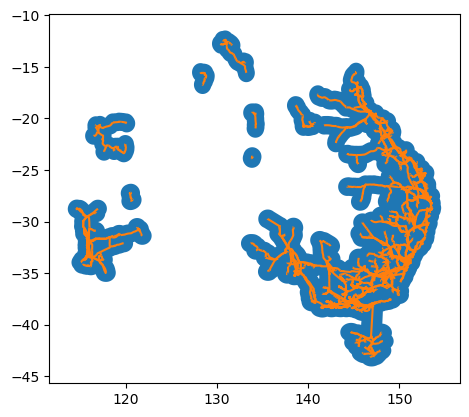

In [35]:
fig,ax=plt.subplots(1, 1)
gdf_out.plot(ax=ax)
gdf.plot(ax=ax, color="tab:orange")

In [36]:
def get_swis_mask(gdf, template, orog, extent=[110, 155, -45, -10]):
    """
    Return SWIS mask on template grid

    gdf: geopandas GeoDataFrame
    template: array, template mask
    orog: array, orography template
    extent: list, of bounding lat/lon coords [W, E, S, N]
    """
    mask = fn.create_mask(gdf, template, extent)
    # Exlude microgrid in NE
    mask = xr.where(
        (mask.lat > -29) & (mask.lon > 119),
        0,
        mask
    )
    mask = xr.where(
        (mask.lat > -25) | (mask.lon > 125),
        0,
        mask
    )
    mask = xr.where(orog > 0, mask, np.nan)
    mask = mask.where(mask > 0)
    return mask.squeeze().drop_vars(["grid", "region"])

In [37]:
def get_nwis_mask(gdf, template, orog, extent=[110, 155, -45, -10]):
    """
    Return NWIS mask on template grid

    gdf: geopandas GeoDataFrame
    template: array, template mask
    orog: array, orography template
    extent: list, of bounding lat/lon coords [W, E, S, N]
    """
    mask = fn.create_mask(gdf, template, extent)
    # Exlude microgrid in NE
    mask = xr.where(
        (mask.lat > -25) & (mask.lon < 122),
        mask,
        0
    )
    mask = xr.where(orog > 0, mask, np.nan)
    mask = mask.where(mask > 0)
    return mask.squeeze().drop_vars(["grid", "region"])

In [38]:
orog_barraR2 = xr.open_dataset(
    "/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/fx/orog/latest/orog_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1.nc"
)["orog"].sel(lat=barraR2_grid_mask.lat, lon=barraR2_grid_mask.lon)

In [39]:
barraR2_nwis_mask = get_nwis_mask(gdf_out, barraR2_grid_mask.isel(grid=0).wind_2025, orog_barraR2)
barraR2_swis_mask = get_swis_mask(gdf_out, barraR2_grid_mask.isel(grid=0).wind_2025, orog_barraR2)

In [40]:
lsm_era5 = xr.open_mfdataset(
    "/g/data/rt52/era5/single-levels/monthly-averaged/lsm/2025/lsm_era5_moda_sfc_20250101-20250131.nc"
)["lsm"]

In [41]:
lsm_era5 = lsm_era5.isel(time=0).sel(
    latitude=era5_grid_mask.lat, longitude=era5_grid_mask.lon
)

In [42]:
# Count land as any grid cell with at least 20% land
lsm_era5 = xr.where(lsm_era5 >= 0.2, 1, 0)

In [43]:
era5_nwis_mask = get_nwis_mask(
    gdf_out,
    era5_grid_mask.isel(grid=0).wind_2025.sel(lat=slice(None, None, -1)),
    lsm_era5.sel(lat=slice(None, None, -1))
).sel(lat=slice(None, None, -1))

era5_swis_mask = get_swis_mask(
    gdf_out,
    era5_grid_mask.isel(grid=0).wind_2025.sel(lat=slice(None, None, -1)),
    lsm_era5.sel(lat=slice(None, None, -1))
).sel(lat=slice(None, None, -1))

### Plot mean wind speed with grids shown

In [51]:
from dask.distributed import Client,LocalCluster
from dask_jobqueue import PBSCluster

In [52]:
PROJECT = "dt6"

In [53]:
walltime = "01:00:00"
cores = 24
memory = str(4 * cores) + "GB"

cluster = PBSCluster(
    walltime=str(walltime),
    cores=cores,
    memory=str(memory),
    processes=cores,
    job_extra_directives=[
        "-q normal",
        "-P "+PROJECT,
        "-l ncpus="+str(cores),
        "-l mem="+str(memory),
        "-l storage=gdata/xp65+gdata/ob53+gdata/w42+scratch/w42+gdata/gb02+scratch/gb02+gdata/ng72+scratch/ng72+gdata/rt52"
    ],
    local_directory="$TMPDIR",
    job_directives_skip=["select"],
    log_directory="/scratch/w42/dr6273/tmp/logs"
)

INFO:dask_jobqueue.pbs:Resource specification for PBS not set, initializing it to select=1:ncpus=24:mem=90GB


In [54]:
cluster.scale(jobs=1)
client = Client(cluster)

INFO:dask_jobqueue.pbs:Resource specification for PBS not set, initializing it to select=1:ncpus=24:mem=90GB


In [55]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.6.121.7:46431,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [56]:
era5_10m = xr.open_zarr(
    FILEPATH + "ERA5/ws10m_era5_daily_Aus.zarr",
    consolidated=True
)["ws10m"].sel(time=YEARS)

In [58]:
era5_10m_mean = era5_10m.mean("time").compute()

In [59]:
barraR2_10m = xr.open_mfdataset(
    glob.glob(FILEPATH + "BARRA-R2/wss*")
)["wss"]

In [60]:
barraR2_10m_mean = barraR2_10m.mean("time").compute()

In [163]:
def plot_regions(ax, da, masks):
    """
    Plot array with regions outlined

    ax: axes
    da: array, data to plot
    masks: list of arrays, binary arrays to contour around
    """
    colors = ["tab:pink", "tab:orange", "tab:red"]
    
    im = ax.pcolormesh(da.lon, da.lat, da, vmin=0, vmax=12)
    plt.colorbar(im, ax=ax, label='Wind speed [m/s]')

    for mask, color in zip(masks, colors):
        # add contour outline where mask = 1
        mask = xr.where(mask.notnull(), 1, 0)
        ax.contour(
            da.lon,
            da.lat,
            mask,
            levels=[0.5],
            colors=color,
            linewidths=1
        )

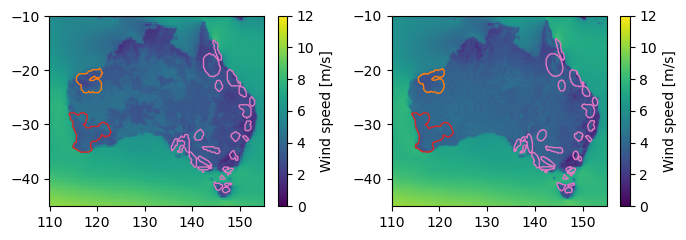

In [164]:
fig, ax = plt.subplots(1, 2, figsize=(7,2.5))
plot_regions(
    ax[0],
    era5_10m_mean,
    [era5_grid_mask.wind_2050.sel(grid="NEM"), era5_nwis_mask, era5_swis_mask]
)
plot_regions(
    ax[1],
    barraR2_10m_mean,
    [barraR2_grid_mask.wind_2050.sel(grid="NEM"), barraR2_nwis_mask, barraR2_swis_mask]
)
plt.tight_layout()

In [47]:
filenames = [
    "grid_mask_NEM_era5.nc",
    "grid_mask_SWIS_era5.nc",
    "grid_mask_NWIS_era5.nc",
    "grid_mask_NEM_BARRA-R2.nc",
    "grid_mask_SWIS_BARRA-R2.nc",
    "grid_mask_NWIS_BARRA-R2.nc"
]

In [48]:
masks = [
    era5_grid_mask,
    era5_swis_mask,
    era5_nwis_mask,
    barraR2_grid_mask,
    barraR2_swis_mask,
    barraR2_nwis_mask
]

In [49]:
for filename, mask in zip(filenames, masks):
    mask.to_netcdf(FILEPATH + filename, mode="w")